In [1]:
import cv2
import matplotlib.pyplot as plt

In [6]:
from sklearn.cluster import KMeans

In [2]:
image_path = "../output_videos/cropped_image_1.jpg"

In [3]:
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

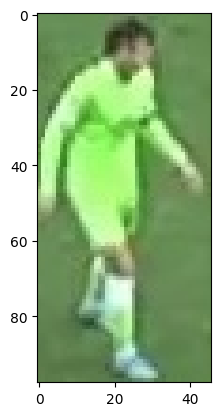

In [4]:
plt.imshow(image)
plt.show()

## Taking the top half of the Image

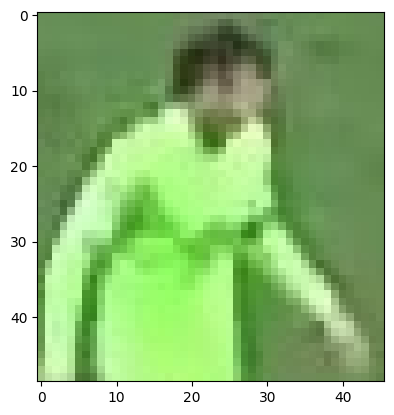

In [5]:
top_half_image = image[0: int(image.shape[0]/2),:]
plt.imshow(top_half_image)
plt.show()

Cluster the image into two cluster

In [12]:
# removing the background
image_2d = top_half_image.reshape(-1,3)

In [13]:
kmeans = KMeans(n_clusters=2, random_state=0).fit(image_2d)

In [14]:
# get the cluster labels
labels = kmeans.labels_
print(labels)

[0 0 0 ... 0 0 0]


In [15]:
# reshape the labels into original image
clustered_image = labels.reshape(top_half_image.shape[0], top_half_image.shape[1])

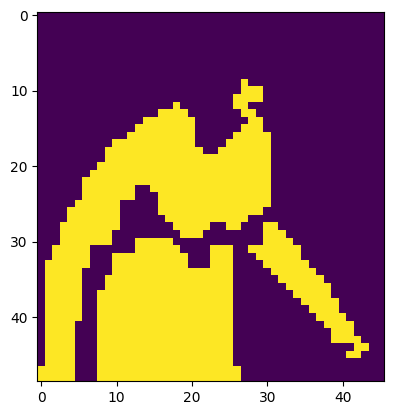

In [16]:
plt.imshow(clustered_image)
plt.show()

In [17]:
corner_clusters = [clustered_image[0,0], clustered_image[0,-1], clustered_image[-1,0], clustered_image[-1,-1]]

In [18]:
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)

In [19]:
print(non_player_cluster)

0


In [20]:
player_cluster = 1 - non_player_cluster
print(player_cluster)

1


In [21]:
kmeans.cluster_centers_[player_cluster]

array([176.23893805, 242.6346397 , 140.2300885 ])